本次实战内容是探究各个因素与自行车出行数量之间的关系，本次的内容主要从读取数据、评估并整理数据，探索数据、模型分析数据、评估模型这五个方面来进行展开

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib import rcParams

# 一、读取数据

In [3]:
original_data = pd.read_csv(r'C:\Users\废话笔记本\Desktop\假设检验练习\github上传文件\train.csv')
original_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2017-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2017-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2017-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2017-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2017-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


# 二、评估数据

评估数据主要从两个方面进行，分别是结构和内容，结构方面的问题主要是指不符合每个变量是一列，每行是一个观察值，每种类型的观察单位是一个表格
内容问题是指数据不存在缺失值、重复值、无效值和不一致值。
为了不更改原数据内容，通常要先对数据进行复制

In [4]:
cleaned_data = original_data.copy()

## 1、结构问题的处理

In [5]:
cleaned_data.sample(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
1138,2017-03-12 02:00:00,1,0,0,1,9.84,11.365,65,12.9980,0,14,14
404,2017-01-18 20:00:00,1,0,1,2,9.02,13.635,87,0.0000,0,83,83
1581,2017-04-11 19:00:00,2,0,1,1,29.52,33.335,51,30.0026,73,211,284
4087,2017-10-02 08:00:00,4,0,0,2,13.94,16.665,76,12.9980,14,50,64
724,2017-02-13 13:00:00,1,0,0,1,15.58,19.695,29,23.9994,62,92,154
5001,2017-12-02 11:00:00,4,0,1,1,13.94,16.665,66,11.0014,18,142,160
4686,2017-11-08 08:00:00,4,0,1,1,13.12,16.665,93,7.0015,11,455,466
5935,2018-02-03 12:00:00,1,0,1,1,13.94,16.665,46,8.9981,25,191,216
925,2017-03-03 00:00:00,1,0,1,1,9.84,9.850,30,31.0009,3,10,13
576,2017-02-07 04:00:00,1,0,1,1,8.20,12.880,86,0.0000,1,1,2


结论：从任意十条数据可以大致看出，数据不存在结构性问题

## 2.内容问题的处理

In [6]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


首先通过info信息我们可以看出数据的格式、数量，目前看并未存在缺失值，但是日期应该转成时间序列

### （1）.处理时间格式

In [7]:
#利用DatetimeIndex将某一列进行转换并将该列设置为索引
cleaned_data['month'] = pd.DatetimeIndex(cleaned_data.datetime).month#月份
cleaned_data['day'] = pd.DatetimeIndex(cleaned_data.datetime).weekday#周几
cleaned_data['hour'] = pd.DatetimeIndex(cleaned_data.datetime).hour#时段

In [8]:
cleaned_data = cleaned_data.drop('datetime',axis = 1)

In [9]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
 11  month       10886 non-null  int32  
 12  day         10886 non-null  int32  
 13  hour        10886 non-null  int32  
dtypes: float64(3), int32(3), int64(8)
memory usage: 1.0 MB


### （2）.处理缺失值

从info信息中我们可以看到该数据中不存在缺失值，因此本项内容不需要处理

### （3）.处理重复值

In [10]:
cleaned_data.duplicated().sum()

1

该数据中不存在重复值

### （4）.处理不一致值

处理不一致值是看变量中的分组情况，因此对数据中season、holiday、workingday、weather四个分类变量进行检查

In [11]:
cleaned_data[['season','holiday','workingday','weather']].value_counts()

season  holiday  workingday  weather
3       0        1           1          1306
2       0        1           1          1244
1       0        1           1          1213
4       0        1           1          1076
                             2           591
3       0        0           1           572
4       0        0           1           557
2       0        0           1           516
1       0        0           1           504
                 1           2           474
2       0        1           2           468
3       0        1           2           404
2       0        0           2           233
1       0        0           2           218
4       0        0           2           194
2       0        1           3           181
4       0        1           3           179
3       0        0           2           160
1       0        1           3           140
3       0        1           3           135
4       1        0           1            69
1       0        0

### （5）.处理无效值

In [12]:
cleaned_data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,day,hour
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,6.521495,3.011574,11.541613
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,3.444373,2.012011,6.915838
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,4.000000,1.000000,6.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,7.000000,3.000000,12.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,10.000000,5.000000,18.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,12.000000,6.000000,23.000000


从描述性信息来看，数据的标准差最大值、最小值、分位数等均正常，不存在无效值

# 三、探索分析

首先利用箱型图来探索单个分类变量与因变量之间的关系，再利用折现图探究单个连续变量与因变量之间的关系，最后利用热力图探索各个变量之间的相关性

## 1、季节与数量之间的关系

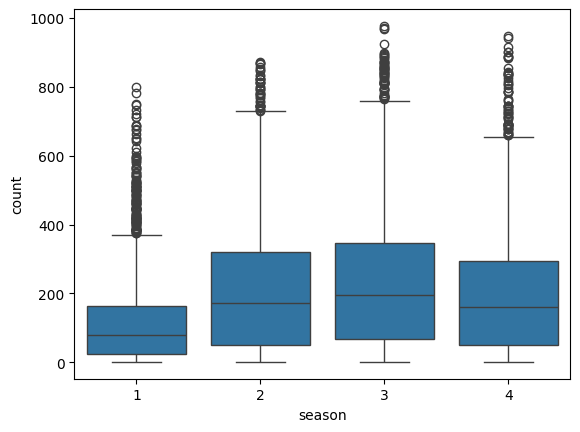

In [13]:
sns.boxplot(cleaned_data,x='season',y = 'count')
plt.show()

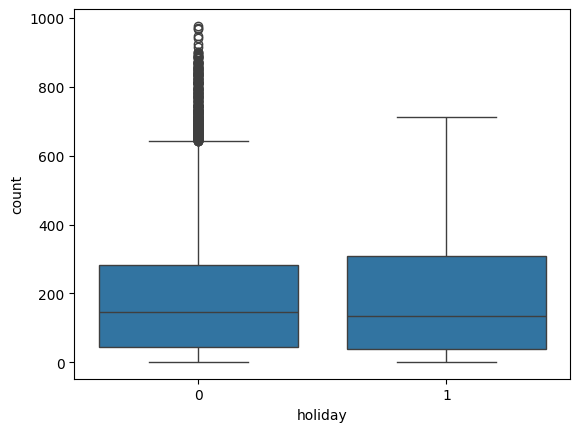

In [14]:
sns.boxplot(cleaned_data,x='holiday',y = 'count')
plt.show()

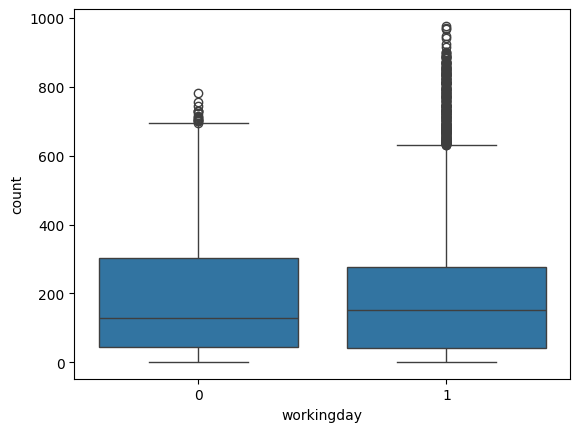

In [15]:
sns.boxplot(cleaned_data,x='workingday',y = 'count')
plt.show()

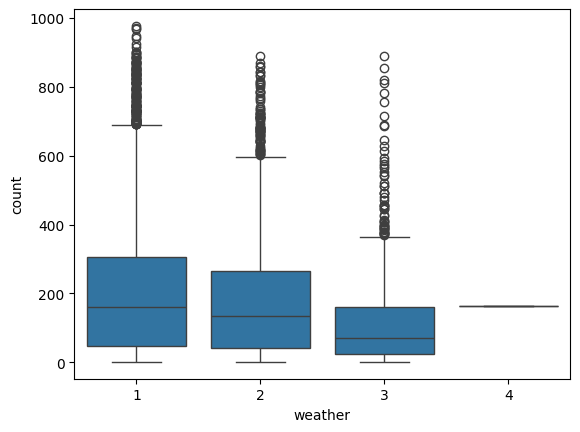

In [16]:
sns.boxplot(cleaned_data,x='weather',y = 'count')
plt.show()

In [18]:
temp_cut = pd.cut(cleaned_data['temp'],bins = 5)
print(temp_cut.value_counts())

temp
(16.892, 24.928]    3340
(8.856, 16.892]     3331
(24.928, 32.964]    3095
(0.78, 8.856]        717
(32.964, 41.0]       403
Name: count, dtype: int64


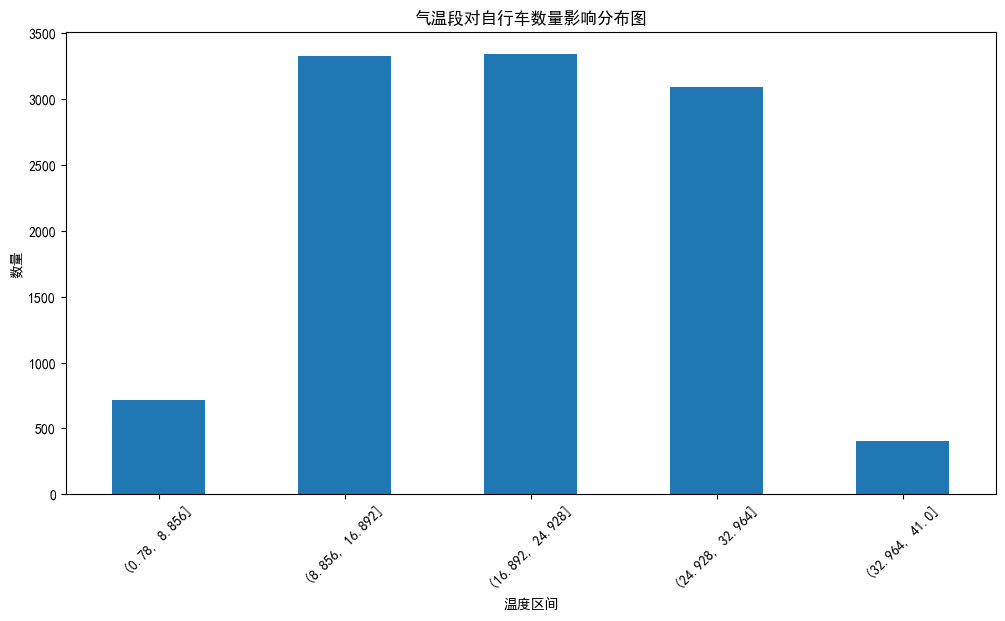

In [23]:
plt.figure(figsize = (12,6))
rcParams['font.family'] = 'SimHei'
temp_cut.value_counts().sort_index().plot(kind='bar')
plt.xlabel('温度区间')
plt.ylabel('数量')
plt.title('气温段对自行车数量影响分布图')
plt.xticks(rotation=45)
plt.show()

In [20]:
humidity_cut = pd.cut(cleaned_data['humidity'],bins = 5)
print(humidity_cut.value_counts())

humidity
(40.0, 60.0]     3564
(60.0, 80.0]     3382
(80.0, 100.0]    2302
(20.0, 40.0]     1560
(-0.1, 20.0]       78
Name: count, dtype: int64


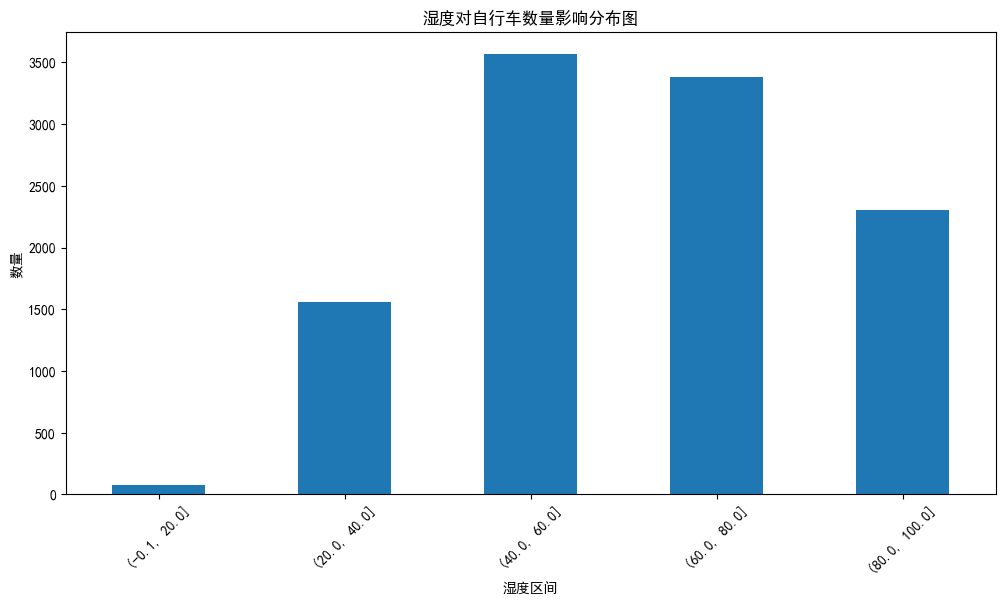

In [24]:
plt.figure(figsize = (12,6))
rcParams['font.family'] = 'SimHei'
humidity_cut.value_counts().sort_index().plot(kind = 'bar')
plt.xlabel('湿度区间')
plt.ylabel('数量')
plt.title('湿度对自行车数量影响分布图')
plt.xticks(rotation=45)
plt.show()

结论：温度过高或者过低都会影响大家出行的热情，空气过于干燥大家也不愿意出行。

以上是做了两个元素的分箱示例，其他两个不做演示

D:\python\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.draw()
D:\python\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


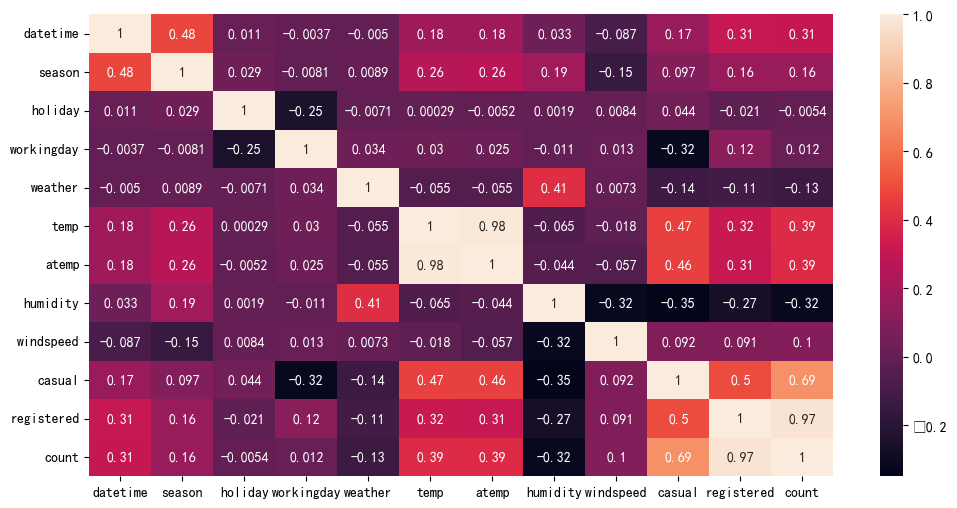

In [30]:
plt.figure(figsize = (12,6))
corr = cleaned_data.corr()
sns.heatmap(corr,annot = True)
plt.show()

# 四、模型构建

In [12]:
bicycle_data = cleaned_data.drop(['count','casual','registered'],axis = 1)#提取数据变量
bicycle_target = cleaned_data['count']#提取标签变量

In [13]:
from sklearn.model_selection import train_test_split
bicycle_data_train,bicycle_data_test,bicycle_target_train,bicycle_target_test = \
train_test_split(bicycle_data,bicycle_target,test_size = 0.2,random_state= 42)#区分训练集和测试集

In [14]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 100,random_state = 42).fit(bicycle_data_train,bicycle_target_train)#构造函数

In [15]:
y_pred = model.predict(bicycle_data_test)


In [16]:
bicycle_data_test.shape

(2178, 11)

# 五、评价模型

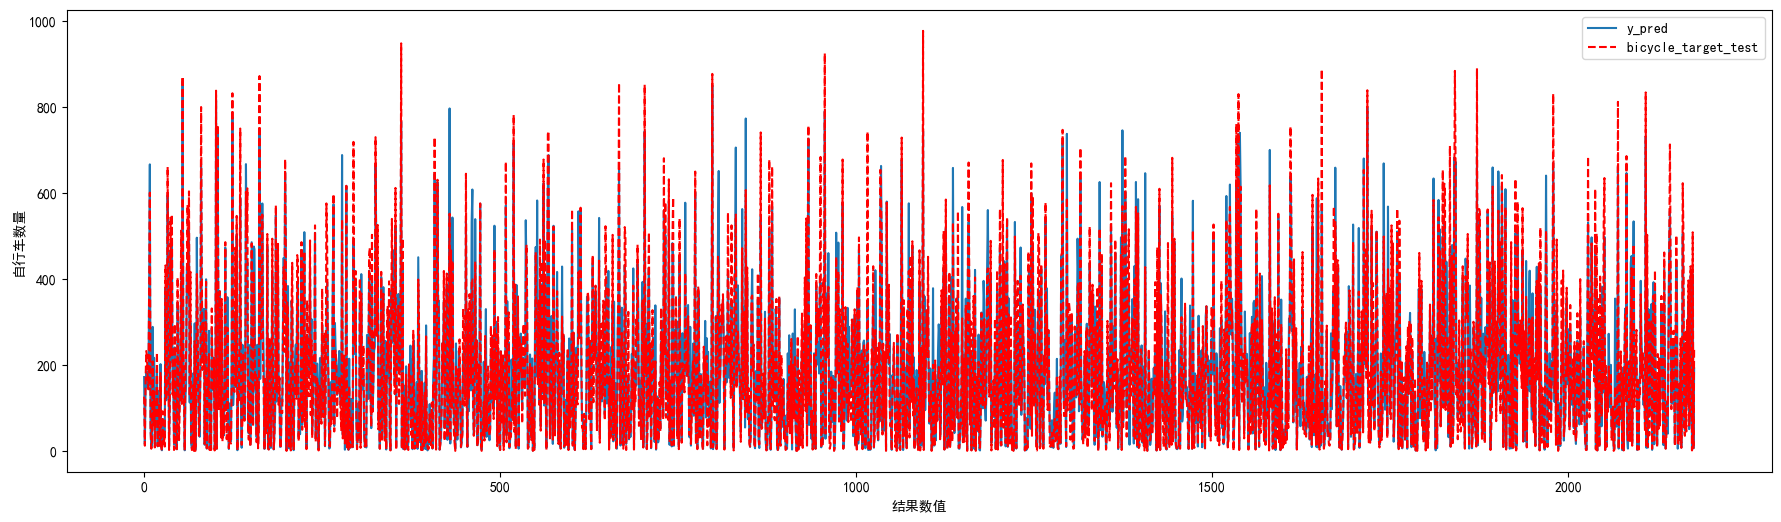

In [17]:
rcParams['font.family'] = 'SimHei'
fig = plt.figure(figsize = (22,6))
plt.plot(range(bicycle_data_test.shape[0]),y_pred)
plt.plot(range(bicycle_data_test.shape[0]),bicycle_target_test,color = 'red',linestyle = '--')
plt.xlabel('结果数值')
plt.ylabel('自行车数量')
plt.legend(['y_pred','bicycle_target_test'])

In [18]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [19]:
print('R2为：',r2_score(bicycle_target_test,y_pred))

R2为： 0.8828503746668563


In [20]:
print('MSE为：',mean_squared_error(bicycle_target_test,y_pred))

MSE为： 3866.7501699841328


In [22]:
cleaned_data['count'].mean()

191.57413191254824

In [21]:
print('MAE为：',mean_absolute_error(bicycle_target_test,y_pred))

MAE为： 41.42893180724999


In [ ]:
结论：从图像来看，预测值和测试集的结果能够基本吻合，R2为0.88，但是rmse/191 = 32.5%说明随机森林模型学习了数据的整体趋势，但整体精度不足，可能存在系统性的预测偏差